# LaCAM + PIBT + primitive demo
This notebook runs the planner once, retains every anytime incumbent, and lets you compare smooth/waypoint-only animations without searching again.

In [1]:
from pathlib import Path    
import subprocess, sys, yaml
from IPython.display import Image, display
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'python'))
from lacam_primitive_viz import plan_and_animate

In [2]:
subprocess.run(['cmake', '-S', str(REPO), '-B', str(REPO / 'build'), '-DCMAKE_BUILD_TYPE=Release'], check=True)
subprocess.run(['cmake', '--build', str(REPO / 'build'), '-j2'], check=True)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kakitsu/tel/lacam_primitive/build
[ 63%] Built target lacam_primitive_core
[ 81%] Built target lacam_primitive
[100%] Built target lacam_primitive_tests


CompletedProcess(args=['cmake', '--build', '/home/kakitsu/tel/lacam_primitive/build', '-j2'], returncode=0)

In [21]:
time_limit_ms = 10000
anytime = True  # Keep the fast incumbent and any improvements found by 50 ms.
initial_weight = 2.0
max_branching = 4  # acceleration ON low-latency profile
initial_solution_max_branching = None  # e.g. 3 for a staged incumbent pass
alternatives_per_agent = 4  # acceleration OFF fastest profile: 2
transition_cache = True
candidate_cache = True
ara_star = True
dynamics_aware_pibt = True
interval_dominance = True
multiple_rotation_amounts = True
acceleration_constraints = True

#transition_cache = False
#candidate_cache = False
#ara_star = False

collision_mode = "time_indexed"  # or "whole_step"
max_boundary_travel_per_interval_m = 0.005  # 5 mm

# Physical-size scale: changing cell_size no longer changes the canvas size.
pixels_per_meter = 240

artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    #REPO / "outputs" / "notebook_rotation_pivot",
    REPO / "outputs" / "notebook",
    time_limit_ms=time_limit_ms,
    anytime=anytime,
    initial_weight=initial_weight,
    max_branching=max_branching,
    initial_solution_max_branching=initial_solution_max_branching,
    alternatives_per_agent=alternatives_per_agent,
    transition_cache=transition_cache,
    candidate_cache=candidate_cache,
    ara_star=ara_star,
    dynamics_aware_pibt=dynamics_aware_pibt,
    interval_dominance=interval_dominance,
    multiple_rotation_amounts=multiple_rotation_amounts,
    acceleration_constraints=acceleration_constraints,
    collision_mode=collision_mode,
    max_boundary_travel_per_interval_m=max_boundary_travel_per_interval_m,
    pixels_per_meter=pixels_per_meter,
    animation_modes=("smooth", "waypoints"),
    include_all_solutions=True,
)
artifacts

solution improved: cost=7 weight=2 search_ms=22.4475
precompute static: 18.4401 ms (primitive/collision=11.8621, transition_cache=6.51897, connection_rules=0.058405)
precompute query: 1.4007 ms (candidate_cache=1.39391)
search: 115.835 ms
first solution: 22.4092 ms, cost=7
warm request: 117.235 ms
cold total: 135.675 ms
modes: transition_cache=on candidate_cache=on ara_star=on reverse_bfs=on diversification=on aabb=on conflict_cache=on lazy=off widening=on initial_width=4 initial_solution_branching=0 per_primitive_intervals=on multiple_rotations=on acceleration_constraints=on dynamics_aware_pibt=on interval_dominance=on pivot_anchor_lattice=on active_rotation_amounts=2 collision_mode=time_indexed max_boundary_travel_per_interval_m=0.005 collision_intervals=231 interval_polygons=15192
cache stats: transition 409181/409181 hits, candidate 7221/7221 hits, expanded_nodes=2407, low_level_nodes=33289, kinematic_validations=1, kinematic_failures=0, kinematic_restarts=0, kinematic_no_goods=0, 

{'solution': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution.yaml'),
 'animation': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution_00_cost_7_smooth.gif'),
 'animations': [{'solution_index': 0,
   'cost': 7,
   'weight': 2,
   'elapsed_ms': 22.409232,
   'mode': 'smooth',
   'path': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution_00_cost_7_smooth.gif')},
  {'solution_index': 0,
   'cost': 7,
   'weight': 2,
   'elapsed_ms': 22.409232,
   'mode': 'waypoints',
   'path': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution_00_cost_7_waypoints.gif')}]}

In [22]:
with artifacts['solution'].open(encoding='utf-8') as stream:
    solution = yaml.safe_load(stream)
with (REPO / 'examples' / 'example.yaml').open(encoding='utf-8') as stream:
    problem = yaml.safe_load(stream)

dt = float(problem['grid']['macro_dt'])
agent_costs = [len(plan['primitive_ids']) * dt for plan in solution['plans']]

# このLaCAM-style探索はsuccessor数を制限するため、大域最適性を証明しない。
optimal = solution.get('optimal', 'not certified')
lower_bound = solution.get('lower_bound')
statistics = {
    'timing': solution.get('timing', {}),
    'runtime': solution.get('runtime', {}),
}
source = (
    'ara_star'
    if solution.get('runtime', {}).get('ara_star_enabled')
    else 'repeated_weighted_search'
)

print('objective       :', solution['objective'])
print('reported cost   :', solution.get('cost'))
print('per-agent costs :', agent_costs)
print('sum of costs    :', sum(agent_costs))
print('makespan        :', max(agent_costs) if agent_costs else None)
print('optimal / LB    :', optimal, '/', lower_bound)
print('statistics      :', statistics)
print('improvements    :')
for sequence, item in enumerate(solution.get('improvements', [])):
    print({
        'sequence': sequence,
        'cost': item.get('cost'),
        'lower_bound': item.get('lower_bound'),
        'elapsed_ms': item.get('elapsed_ms'),
        'source': item.get('source', source),
    })

objective       : makespan
reported cost   : 7
per-agent costs : [7.0, 7.0, 7.0]
sum of costs    : 21.0
makespan        : 7.0
optimal / LB    : not certified / None
statistics      : {'timing': {'primitive_collision_precompute_ms': 11.862135, 'transition_cache_precompute_ms': 6.518967, 'static_precompute_ms': 18.440057, 'candidate_cache_precompute_ms': 1.393909, 'connection_rule_precompute_ms': 0.058405, 'query_precompute_ms': 1.400696, 'search_ms': 115.834572, 'first_solution_ms': 22.409232, 'first_solution_cost': 7, 'warm_request_ms': 117.235268, 'cold_total_ms': 135.675325}, 'runtime': {'transition_cache_enabled': True, 'candidate_cache_enabled': True, 'ara_star_enabled': True, 'reverse_bfs_heuristic_enabled': True, 'candidate_diversification_enabled': True, 'aabb_broadphase_enabled': True, 'conflict_cache_enabled': True, 'lazy_successors_enabled': False, 'progressive_widening_enabled': True, 'initial_candidate_width': 4, 'initial_solution_max_branching': 0, 'per_primitive_intervals

'cost=7, weight=2, found at 22.4 ms'

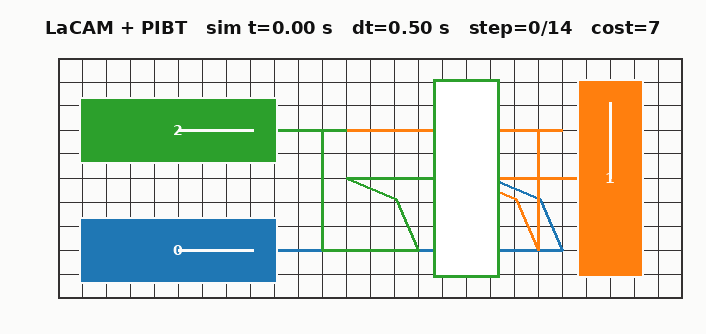

In [23]:
# Select an incumbent and rendering mode without rerunning the planner.
#animation_mode = "smooth"  # or "waypoints"
animation_mode = "waypoints"
available = [item for item in artifacts['animations']
             if item['mode'] == animation_mode]
selected = available[-1]  # -1: lowest-cost incumbent, 0: first incumbent
display(f"cost={selected['cost']}, weight={selected['weight']}, "
        f"found at {selected['elapsed_ms']:.1f} ms")
display(Image(filename=str(selected['path'])))

In [ ]:
selected